# Eksperiment 2-12 — Razlika formi (EMA 25%)


In [6]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from experiment_utils import save_result_v1, run_one_experiment, run, MLPClassifier

In [2]:
FEATURE_COLS = ["form_diff_ema25"]

data = pd.read_csv("../data/Processed_Project_Data/fifa_and_elo_with_ema.csv")
data = data.dropna(subset=FEATURE_COLS + ["result"])

X = data[FEATURE_COLS].values.astype(np.float32)
y = (data["result"].values + 1).astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle = False
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Train size:", len(X_train_tensor), "Test size:", len(X_test_tensor))

Train size: 888 Test size: 222


In [3]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 1.0078 | val loss = 0.9176 | val acc = 0.6011
Epoch 100/1000 | train loss = 1.0039 | val loss = 0.9212 | val acc = 0.6124
Epoch 150/1000 | train loss = 1.0075 | val loss = 0.9259 | val acc = 0.6124
Epoch 200/1000 | train loss = 1.0036 | val loss = 0.9211 | val acc = 0.6067
Epoch 250/1000 | train loss = 1.0049 | val loss = 0.9195 | val acc = 0.6011
Epoch 300/1000 | train loss = 1.0063 | val loss = 0.9177 | val acc = 0.6067
Epoch 350/1000 | train loss = 1.0065 | val loss = 0.9205 | val acc = 0.6067
Epoch 400/1000 | train loss = 1.0032 | val loss = 0.9226 | val acc = 0.6067
Epoch 450/1000 | train loss = 1.0022 | val loss = 0.9182 | val acc = 0.6067
Epoch 500/1000 | train loss = 1.0011 | val loss = 0.9163 | val acc = 0.6067
Epoch 550/1000 | train loss = 1.0105 | val loss = 0.9225 | val acc = 0.6067
Epoch 600/1000 | train loss = 1.0046 | val loss = 0.9226 | val acc = 0.6067
Epoch 650/1000 | train loss = 0.9996 | val loss = 0.9238 | val acc = 0.6067
Epoch 700/100

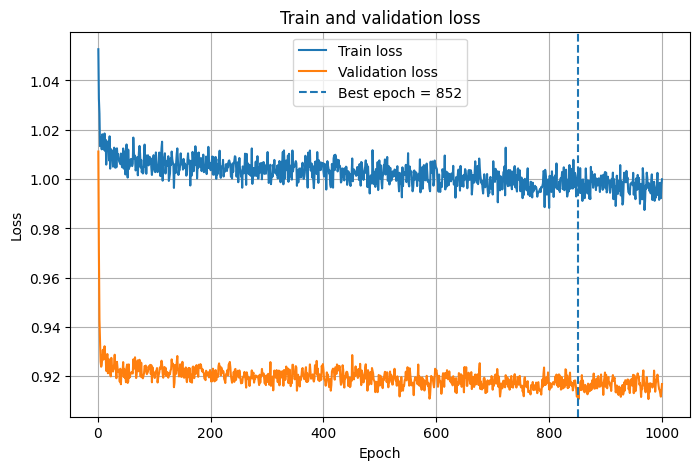

0.509009009009009

In [4]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [5]:
best_num_epochs = 852

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.5090 | Precision: 0.3256 | Recall: 0.4420 | Specificity: 0.7221 | F1: 0.3723

Run 2/10
Accuracy: 0.5180 | Precision: 0.3340 | Recall: 0.4484 | Specificity: 0.7252 | F1: 0.3790

Run 3/10
Accuracy: 0.5090 | Precision: 0.3256 | Recall: 0.4420 | Specificity: 0.7221 | F1: 0.3723

Run 4/10
Accuracy: 0.5135 | Precision: 0.3297 | Recall: 0.4480 | Specificity: 0.7249 | F1: 0.3775

Run 5/10
Accuracy: 0.5180 | Precision: 0.3340 | Recall: 0.4484 | Specificity: 0.7252 | F1: 0.3790

Run 6/10
Accuracy: 0.5135 | Precision: 0.3305 | Recall: 0.4452 | Specificity: 0.7232 | F1: 0.3759

Run 7/10
Accuracy: 0.5270 | Precision: 0.3433 | Recall: 0.4549 | Specificity: 0.7284 | F1: 0.3859

Run 8/10
Accuracy: 0.5180 | Precision: 0.3340 | Recall: 0.4484 | Specificity: 0.7252 | F1: 0.3790

Run 9/10
Accuracy: 0.5225 | Precision: 0.3394 | Recall: 0.4517 | Specificity: 0.7264 | F1: 0.3827

Run 10/10
Accuracy: 0.5090 | Precision: 0.3256 | Recall: 0.4420 | Specificity: 0.7221 | F1: 0.3723

Summary o

In [7]:
save_result_v1(
    experiment_name="Experiment_2-12_EMA25_diff",
    summary=summary
)


Saved result for Experiment_2-12_EMA25_diff
File: ../results/experiment_summary_v1.csv
